# Physics-Informed Hybrid Observables on Directional Advection

This notebook compares three Koopman models on directional grid advection:

1. **Pure GNN** — learned lifting only.
2. **Laplacian preset hybrid** — prepends ``L_norm @ x`` via
   ``physics_preset='graph_laplacian'``.
3. **Custom hybrid** — prepends west/north neighbor states via a user-defined
   ``physics_lifting_fn``.

The benchmark is
:class:`~koopman_graph.datasets.AnisotropicAdvectionGridBenchmark`, where node
features evolve through **asymmetric** weighted neighbor mixing (west/north
directions dominate) with self-retention — advection-like dynamics on a grid,
not exact symmetric Laplacian diffusion. Injecting ``L_norm @ x`` supplies a
**symmetric structural prior**; a custom directional prior can align more
closely with the true update rule.

**Scope:** Results use a single random seed and one train/val/test split.
Treat this as an illustrative API tutorial, not a benchmark paper claim.
Long-horizon RMSE is seed-sensitive for unconstrained dense ``K``.

## Workflow

1. **Encode (GNN lifting):** A GCN encoder maps node features into a learned
   latent ``z_gnn``.
2. **Physics lift (optional):** supply either a built-in preset
   (``physics_preset='graph_laplacian'``) or a custom callable
   ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)`` features.
   Physics features are prepended: ``z = [z_physics || z_gnn]``.
3. **Koopman step:** A learned matrix ``K`` advances the combined latent state.
4. **Decode:** A GCN decoder maps latent states back to physical features.

Set ``physics_dim`` explicitly and ensure
``latent_dim = physics_dim + encoder.latent_dim``. Custom callables are not
serialized — re-supply ``physics_lifting_fn`` on
:meth:`~koopman_graph.model.GraphKoopmanModel.load`.

In [1]:
import os
import tempfile
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import temporal_split
from koopman_graph.datasets import AnisotropicAdvectionGridBenchmark

## 1. Data and train/val/test split

We generate 100 snapshots on an 8×8 grid. The test split must be long enough
for 12-step open-loop rollouts (``evaluate`` requires
``num_timesteps > max(horizons)``), so we allocate 25% of snapshots to test.

**Capacity note:** All hybrids share the same GNN encoder width
(``encoder.latent_dim = 16``), but total latent width grows with ``physics_dim``
(Laplacian preset: ``16 + 3 = 19``; custom west/north neighbors: ``16 + 6 = 22``).
Improvements reflect both physics features and extra capacity — not a strictly
parameter-matched ablation.

**Fairness:** each model is constructed and trained under the same
``MODEL_SEED`` so initialization RNG does not leak across fits.

In [2]:
DATA_SEED = 0
MODEL_SEED = 1

NUM_TIMESTEPS = 100
NUM_ROWS = 8
NUM_COLS = 8
IN_CHANNELS = 3
GNN_LATENT_DIM = 16
HIDDEN = 32
TIME_STEP = 0.1
EPOCHS = 50
LR = 5e-3
EVAL_HORIZONS = [3, 6, 12]

torch.manual_seed(DATA_SEED)
sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    seed=DATA_SEED,
)
split = temporal_split(
    sequence,
    train_ratio=0.6,
    val_ratio=0.15,
    test_ratio=0.25,
)

print(
    f"nodes={sequence.num_nodes}, "
    f"train={split.train.num_timesteps}, "
    f"val={split.val.num_timesteps}, "
    f"test={split.test.num_timesteps}"
)

nodes=64, train=60, val=15, test=25


## 2. Custom physics lifting function

The benchmark's dominant transport is **westward and northward** neighbor
mixing. A symmetric Laplacian smooths equally in all directions; here we inject
the **neighbor states themselves** along those axes:

- western neighbor ``x_west`` (self-copy on the western boundary)
- northern neighbor ``x_north`` (self-copy on the northern boundary)

Concatenated, this yields ``physics_dim = 2 * in_channels`` features — distinct
from the Laplacian preset and aligned with the asymmetric update rule.

**Why not deltas?** Features like ``x_west - x`` look like an advection
gradient, but hybrid physics coordinates are encoded **once** and then evolved
linearly by ``K``. Difference features shrink as the field smooths and are easy
for an unconstrained ``K`` to amplify over long rollouts. Absolute neighbor
values are a stabler directional prior for multi-step forecasting.

In [3]:
def directional_advection_features(data: Data) -> torch.Tensor:
    """West- and north-neighbor states for hybrid lifting.

    Boundary nodes without a west/north neighbor copy their own state.
    Absolute neighbor values are stabler long-horizon physics coordinates
    than raw deltas ``x_neighbor - x``, which shrink as the field smooths
    and are easy for unconstrained ``K`` to amplify in open-loop rollout.
    """
    x = data.x
    west = torch.empty_like(x)
    north = torch.empty_like(x)
    for row in range(NUM_ROWS):
        for col in range(NUM_COLS):
            node = row * NUM_COLS + col
            if col > 0:
                west[node] = x[row * NUM_COLS + (col - 1)]
            else:
                west[node] = x[node]
            if row > 0:
                north[node] = x[(row - 1) * NUM_COLS + col]
            else:
                north[node] = x[node]
    return torch.cat([west, north], dim=-1)


CUSTOM_PHYSICS_DIM = 2 * IN_CHANNELS
laplacian_physics_dim = IN_CHANNELS
print(f"Laplacian preset physics_dim={laplacian_physics_dim}")
print(f"Custom directional physics_dim={CUSTOM_PHYSICS_DIM}")

Laplacian preset physics_dim=3
Custom directional physics_dim=6


## 3. Train pure GNN vs hybrid models (preset and custom)

All three models share identical GNN/training hyperparameters. The Laplacian
hybrid uses ``physics_preset='graph_laplacian'``; the custom hybrid passes
``physics_lifting_fn=directional_advection_features`` with no preset.

In [4]:
torch.manual_seed(MODEL_SEED)
pure_model = GraphKoopmanModel(
    encoder=GNNEncoder(
        in_channels=IN_CHANNELS,
        hidden_channels=HIDDEN,
        latent_dim=GNN_LATENT_DIM,
    ),
    decoder=GNNDecoder(
        latent_dim=GNN_LATENT_DIM,
        hidden_channels=HIDDEN,
        out_channels=IN_CHANNELS,
    ),
    latent_dim=GNN_LATENT_DIM,
    time_step=TIME_STEP,
)

torch.manual_seed(MODEL_SEED)
laplacian_total_latent = GNN_LATENT_DIM + laplacian_physics_dim
laplacian_model = GraphKoopmanModel(
    encoder=GNNEncoder(
        in_channels=IN_CHANNELS,
        hidden_channels=HIDDEN,
        latent_dim=GNN_LATENT_DIM,
    ),
    decoder=GNNDecoder(
        latent_dim=laplacian_total_latent,
        hidden_channels=HIDDEN,
        out_channels=IN_CHANNELS,
    ),
    latent_dim=laplacian_total_latent,
    time_step=TIME_STEP,
    physics_preset="graph_laplacian",
    physics_dim=laplacian_physics_dim,
)

torch.manual_seed(MODEL_SEED)
custom_total_latent = GNN_LATENT_DIM + CUSTOM_PHYSICS_DIM
custom_model = GraphKoopmanModel(
    encoder=GNNEncoder(
        in_channels=IN_CHANNELS,
        hidden_channels=HIDDEN,
        latent_dim=GNN_LATENT_DIM,
    ),
    decoder=GNNDecoder(
        latent_dim=custom_total_latent,
        hidden_channels=HIDDEN,
        out_channels=IN_CHANNELS,
    ),
    latent_dim=custom_total_latent,
    time_step=TIME_STEP,
    physics_lifting_fn=directional_advection_features,
    physics_dim=CUSTOM_PHYSICS_DIM,
)

print(
    f"Pure total latent_dim={pure_model.latent_dim}; "
    f"Laplacian hybrid={laplacian_model.latent_dim} "
    f"(gnn={laplacian_model.gnn_latent_dim} + physics={laplacian_model.physics_dim}); "
    f"custom hybrid={custom_model.latent_dim} "
    f"(gnn={custom_model.gnn_latent_dim} + physics={custom_model.physics_dim})"
)

pure_history = pure_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
laplacian_history = laplacian_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
custom_history = custom_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)

print(f"Pure GNN final val loss:      {pure_history.val_loss[-1]:.6f}")
print(f"Laplacian hybrid val loss:    {laplacian_history.val_loss[-1]:.6f}")
print(f"Custom directional val loss:  {custom_history.val_loss[-1]:.6f}")

Pure total latent_dim=16; Laplacian hybrid=19 (gnn=16 + physics=3); custom hybrid=22 (gnn=16 + physics=6)
Pure GNN final val loss:      0.002753
Laplacian hybrid val loss:    0.002593
Custom directional val loss:  0.002336


## 4. Validation loss and rollout comparison

The **left panel** tracks one-step validation loss during ``fit``. The **right
panel** reports multi-step open-loop RMSE on the test split via
:meth:`~koopman_graph.model.GraphKoopmanModel.evaluate`.

One-step val loss and long-horizon RMSE can disagree: physics features are
encoded once and then evolved linearly by ``K``, so a hybrid that looks good
at short horizons can still diverge by step 12 if the operator is unstable.
On this seed, both hybrids beat the pure GNN on held-out rollouts; the
Laplacian preset is strongest overall, while the custom directional prior
still improves over pure GNN at every tested horizon.

Rollout RMSE need not grow monotonically with horizon: metrics are averaged over
multiple forecast origins, and transient mismatch can peak at intermediate
horizons before partially recovering.

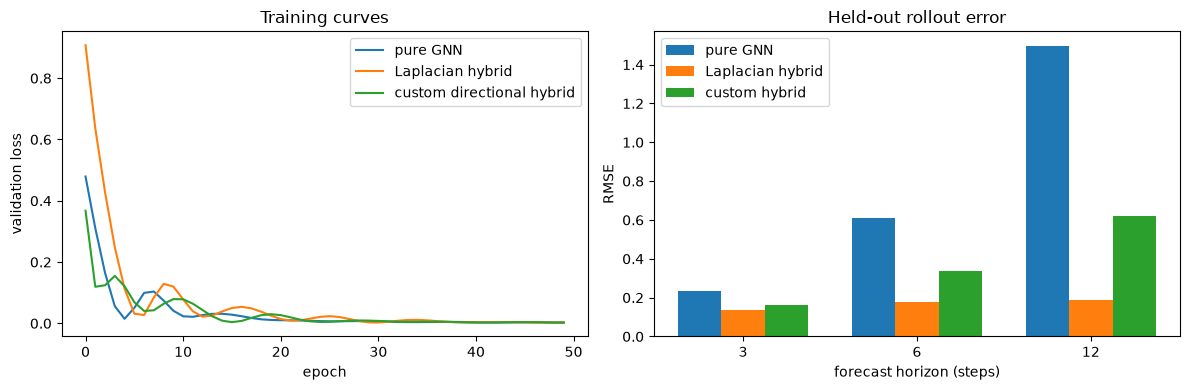

Horizon RMSE (pure / Laplacian / custom):
  h= 3: 0.233172 / 0.137501 / 0.160223
  h= 6: 0.608880 / 0.176280 / 0.335511
  h=12: 1.496448 / 0.187716 / 0.618135


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pure_history.val_loss, label="pure GNN")
axes[0].plot(laplacian_history.val_loss, label="Laplacian hybrid")
axes[0].plot(custom_history.val_loss, label="custom directional hybrid")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation loss")
axes[0].set_title("Training curves")
axes[0].legend()

pure_eval = pure_model.evaluate(split.test, horizons=EVAL_HORIZONS)
laplacian_eval = laplacian_model.evaluate(split.test, horizons=EVAL_HORIZONS)
custom_eval = custom_model.evaluate(split.test, horizons=EVAL_HORIZONS)

pure_by_h = {metric.horizon: metric for metric in pure_eval.horizons}
laplacian_by_h = {metric.horizon: metric for metric in laplacian_eval.horizons}
custom_by_h = {metric.horizon: metric for metric in custom_eval.horizons}
pure_rmse = [pure_by_h[h].rmse for h in EVAL_HORIZONS]
laplacian_rmse = [laplacian_by_h[h].rmse for h in EVAL_HORIZONS]
custom_rmse = [custom_by_h[h].rmse for h in EVAL_HORIZONS]

bar_x = range(len(EVAL_HORIZONS))
bar_width = 0.25
axes[1].bar(
    [i - bar_width for i in bar_x],
    pure_rmse,
    width=bar_width,
    label="pure GNN",
)
axes[1].bar(
    list(bar_x),
    laplacian_rmse,
    width=bar_width,
    label="Laplacian hybrid",
)
axes[1].bar(
    [i + bar_width for i in bar_x],
    custom_rmse,
    width=bar_width,
    label="custom hybrid",
)
axes[1].set_xticks(list(bar_x))
axes[1].set_xticklabels([str(h) for h in EVAL_HORIZONS])
axes[1].set_xlabel("forecast horizon (steps)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Held-out rollout error")
axes[1].legend()

fig.tight_layout()
plt.show()

print("Horizon RMSE (pure / Laplacian / custom):")
for horizon in EVAL_HORIZONS:
    pure = pure_by_h[horizon].rmse
    laplacian = laplacian_by_h[horizon].rmse
    custom = custom_by_h[horizon].rmse
    print(
        f"  h={horizon:2d}: {pure:.6f} / {laplacian:.6f} / {custom:.6f}"
    )

## 5. Save and load with a custom ``physics_lifting_fn``

Checkpoints store ``physics_dim`` but **not** the callable itself. After
``save``, pass the same function to ``load`` so hybrid encoding is restored.

In [6]:
initial = split.test[0]
steps = 3
before_save = custom_model.predict(initial, steps=steps)

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "custom_directional_hybrid.pt"
    custom_model.save(checkpoint_path)
    loaded_custom = GraphKoopmanModel.load(
        checkpoint_path,
        physics_lifting_fn=directional_advection_features,
    )

after_load = loaded_custom.predict(initial, steps=steps)
max_diff = max(
    (before.x - after.x).abs().max().item()
    for before, after in zip(before_save, after_load, strict=True)
)
print(f"Loaded physics_dim={loaded_custom.physics_dim} (preset={loaded_custom.physics_preset})")
print(f"Max |x_before - x_after_load| over {steps} steps: {max_diff:.2e}")
assert max_diff < 1e-5, "save/load round-trip predictions should match"
print("save/load round-trip OK")

Loaded physics_dim=6 (preset=None)
Max |x_before - x_after_load| over 3 steps: 0.00e+00
save/load round-trip OK


## Takeaways

- **Hybrid lifting** concatenates structural and learned features:
  ``z = [z_physics || GNN(x)]``. Use a built-in preset
  (``physics_preset='graph_laplacian'``) or a custom
  ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)`` tensors.
- **Custom example:** ``directional_advection_features`` injects west/north
  neighbor **states** (``physics_dim = 2 * in_channels``). Prefer absolute
  neighbor values over raw deltas for long rollouts: deltas shrink as the
  field smooths and unconstrained ``K`` can amplify them by horizon 12.
- **API:** set ``physics_dim`` explicitly;
  ``latent_dim = physics_dim + encoder.latent_dim``. Checkpoints store
  ``physics_dim`` and optional ``physics_preset``; **re-supply custom callables**
  on :meth:`~koopman_graph.model.GraphKoopmanModel.load`.
- **This run:** both hybrids beat pure-GNN open-loop RMSE at horizons 3/6/12;
  the Laplacian preset is strongest here. Results are seed-sensitive for dense
  ``K`` — do not over-interpret a single seed.
- **Stricter ablation:** match total ``latent_dim``, use structural stability
  modes (``schur`` / ``dissipative``), or average across seeds.
- **Related:** ``04_grid_attention.ipynb`` shows GAT can help when neighbor
  influence is asymmetric; physics priors complement attention, not replace it.